<a href="https://colab.research.google.com/github/Brigada-Inginerilor-Amarati/Prelucrarea-Imaginilor/blob/main/Laborator/Teorie/Notebooks/PI_Laborator_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The Pascal VOC2012 semantic segmentation dataset

When discussing object detection tasks
in *Laboratory 7*,
rectangular bounding boxes
are used to label and predict objects in images.
This laboratory will discuss the problem of *semantic segmentation*,
which focuses on how to divide an image into regions belonging to different semantic classes.
Different from object detection,
semantic segmentation
recognizes and understands
what are in images at pixel level:
its labeling and prediction of semantic regions are
at pixel level.
Compared with in object detection,
the pixel-level borders labeled
in semantic segmentation are obviously more fine-grained.

One of the most important semantic segmentation datasets
is [Pascal VOC2012](http://host.robots.ox.ac.uk/pascal/VOC/voc2012/).
In the following,
we will take a look at this dataset.

In [ ]:
import torch
import torchvision
from torch import nn
from torch.nn import functional as F
from PIL import Image
from matplotlib import pyplot as plt
import os
import requests
import zipfile
import tarfile

We will also need the following functions from the previous laboratories:

In [ ]:
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """Plot a list of images."""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    plt.tight_layout()
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # Tensor Image
            ax.imshow(img.numpy())
        else:
            # PIL Image
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

In [ ]:
def download(url, cache_dir=os.path.join('..', 'data')):
    """Download a file, return the local filename."""
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
        return fname
    print(f'Downloading {fname} from {url}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

def download_extract(url, folder=None):
    """Download and extract a zip file."""
    fname = download(url)
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    elif ext in ('.tar', '.gz'):
        fp = tarfile.open(fname, 'r')
    else:
        assert False, 'Only zip/tar files can be extracted.'
    fp.extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else data_dir

In [ ]:
def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

The tar file of the dataset is about 2 GB,
so it may take a while to download the file.
The extracted dataset is located at `../data/VOCdevkit/VOC2012`.

In [ ]:
voc_dir = download_extract('http://d2l-data.s3-accelerate.amazonaws.com/VOCtrainval_11-May-2012.tar', 'VOCdevkit/VOC2012') #1 min

After entering the path `../data/VOCdevkit/VOC2012`,
we can see the different components of the dataset.
The `ImageSets/Segmentation` path contains text files
that specify training and test samples,
while the `JPEGImages` and `SegmentationClass` paths
store the input image and label for each example, respectively.
The label here is also in the image format,
with the same size
as its labeled input image.
Besides,
pixels with the same color in any label image belong to the same semantic class.
The following defines the `read_voc_images` function to read all the input images and labels into the memory.

In [ ]:
def read_voc_images(voc_dir, is_train=True):
    """Read all VOC feature and label images."""
    txt_fname = os.path.join(voc_dir, 'ImageSets', 'Segmentation',
                             'train.txt' if is_train else 'val.txt')
    mode = torchvision.io.image.ImageReadMode.RGB
    with open(txt_fname, 'r') as f:
        images = f.read().split()
    features, labels = [], []
    for i, fname in enumerate(images):
        features.append(torchvision.io.read_image(os.path.join(
            voc_dir, 'JPEGImages', f'{fname}.jpg')))
        labels.append(torchvision.io.read_image(os.path.join(
            voc_dir, 'SegmentationClass' ,f'{fname}.png'), mode))
    return features, labels

train_features, train_labels = read_voc_images(voc_dir, True)

We draw the first five input images and their labels.
In the label images, white and black represent borders and  background, respectively, while the other colors correspond to different classes.

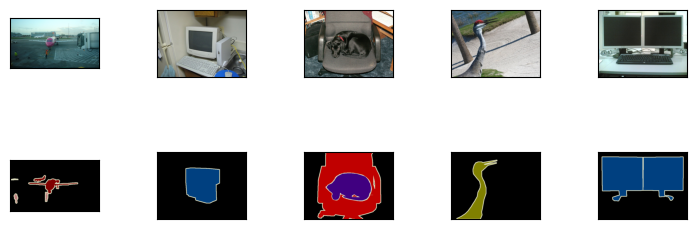

In [ ]:
n = 5
imgs = train_features[:n] + train_labels[:n]
imgs = [img.permute(1,2,0) for img in imgs]
show_images(imgs, 2, n);

Next, we enumerate
the RGB color values and class names
for all the labels in this dataset.

In [ ]:
VOC_COLORMAP = [[0, 0, 0], [128, 0, 0], [0, 128, 0], [128, 128, 0],
                [0, 0, 128], [128, 0, 128], [0, 128, 128], [128, 128, 128],
                [64, 0, 0], [192, 0, 0], [64, 128, 0], [192, 128, 0],
                [64, 0, 128], [192, 0, 128], [64, 128, 128], [192, 128, 128],
                [0, 64, 0], [128, 64, 0], [0, 192, 0], [128, 192, 0],
                [0, 64, 128]]

VOC_CLASSES = ['background', 'aeroplane', 'bicycle', 'bird', 'boat',
               'bottle', 'bus', 'car', 'cat', 'chair', 'cow',
               'diningtable', 'dog', 'horse', 'motorbike', 'person',
               'potted plant', 'sheep', 'sofa', 'train', 'tv/monitor']

With the two constants defined above,
we can conveniently
find the class index for each pixel in a label.
We define the `voc_colormap2label` function
to build the mapping from the above RGB color values
to class indices,
and the `voc_label_indices` function
to map any RGB values to their class indices in this Pascal VOC2012 dataset.

In [ ]:
def voc_colormap2label():
    """Build the mapping from RGB to class indices for VOC labels."""
    colormap2label = torch.zeros(256 ** 3, dtype=torch.long)
    for i, colormap in enumerate(VOC_COLORMAP):
        colormap2label[
            (colormap[0] * 256 + colormap[1]) * 256 + colormap[2]] = i
    return colormap2label

def voc_label_indices(colormap, colormap2label):
    """Map any RGB values in VOC labels to their class indices."""
    colormap = colormap.permute(1, 2, 0).numpy().astype('int32')
    idx = ((colormap[:, :, 0] * 256 + colormap[:, :, 1]) * 256
           + colormap[:, :, 2])
    return colormap2label[idx]

For example, in the first example image,
the class index for the front part of the airplane is $1$,
while the background index is $0$.

In [ ]:
y = voc_label_indices(train_labels[0], voc_colormap2label())
y[105:115, 130:140], VOC_CLASSES[1]

(tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
         [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],
         [0, 0, 0, 0, 0, 0, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 1, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 0, 1, 1, 1, 1],
         [0, 0, 0, 0, 0, 0, 0, 0, 1, 1]]),
 'aeroplane')

In previous experiments
such as those in *Laboratory 4*,
images are rescaled
to fit the model's required input shape.
However, in semantic segmentation,
doing so
requires rescaling the predicted pixel classes
back to the original shape of the input image.
Such rescaling may be inaccurate,
especially for segmented regions with different classes. To avoid this issue,
we crop the image to a *fixed* shape instead of rescaling. Specifically, using random cropping from image augmentation, we crop the same area of
the input image and the label.

In [ ]:
def voc_rand_crop(feature, label, height, width):
    """Randomly crop both feature and label images."""
    rect = torchvision.transforms.RandomCrop.get_params(
        feature, (height, width))
    feature = torchvision.transforms.functional.crop(feature, *rect)
    label = torchvision.transforms.functional.crop(label, *rect)
    return feature, label

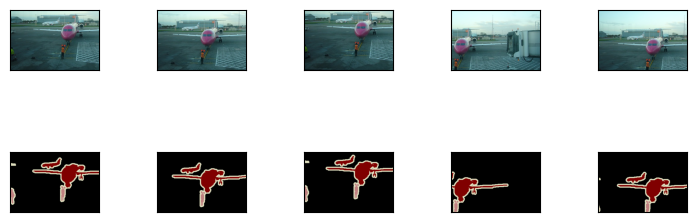

In [ ]:
imgs = []
for _ in range(n):
    imgs += voc_rand_crop(train_features[0], train_labels[0], 200, 300)

imgs = [img.permute(1, 2, 0) for img in imgs]
show_images(imgs[::2] + imgs[1::2], 2, n);

We define a custom semantic segmentation dataset class `VOCSegDataset` by inheriting the `Dataset` class provided by PyTorch.
By implementing the `__getitem__` function,
we can arbitrarily access the input image indexed as `idx` in the dataset and the class index of each pixel in this image.
Since some images in the dataset
have a smaller size
than the output size of random cropping,
these examples are filtered out
by a custom `filter` function.
In addition, we also
define the `normalize_image` function to
standardize the values of the three RGB channels of input images.

In [ ]:
class VOCSegDataset(torch.utils.data.Dataset):
    """A customized dataset to load the VOC dataset."""

    def __init__(self, is_train, crop_size, voc_dir):
        self.transform = torchvision.transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        self.crop_size = crop_size
        features, labels = read_voc_images(voc_dir, is_train=is_train)
        self.features = [self.normalize_image(feature)
                         for feature in self.filter(features)]
        self.labels = self.filter(labels)
        self.colormap2label = voc_colormap2label()
        print('read ' + str(len(self.features)) + ' examples')

    def normalize_image(self, img):
        return self.transform(img.float() / 255)

    def filter(self, imgs):
        return [img for img in imgs if (
            img.shape[1] >= self.crop_size[0] and
            img.shape[2] >= self.crop_size[1])]

    def __getitem__(self, idx):
        feature, label = voc_rand_crop(self.features[idx], self.labels[idx],
                                       *self.crop_size)
        return (feature, voc_label_indices(label, self.colormap2label))

    def __len__(self):
        return len(self.features)

We use the custom `VOCSegDataset` class to
create instances of the training set and test set, respectively.
Suppose that
we specify that the output shape of randomly cropped images is $320\times 480$.
Below we can view the number of examples
that are retained in the training set and test set.

In [ ]:
crop_size = (320, 480)
voc_train = VOCSegDataset(True, crop_size, voc_dir)
voc_test = VOCSegDataset(False, crop_size, voc_dir)

read 1114 examples
read 1078 examples


Setting the batch size to $32$,
we define the data iterator for the training set.
Let's print the shape of the first minibatch.
Different from image classification or object detection, labels here are three-dimensional tensors.

In [ ]:
batch_size = 32
train_iter = torch.utils.data.DataLoader(voc_train, batch_size, shuffle=True,
                                    drop_last=True,
                                    num_workers=2)
for X, Y in train_iter:
    print(X.shape)
    print(Y.shape)
    break

torch.Size([32, 3, 320, 480])
torch.Size([32, 320, 480])


Finally, we define the following `load_data_voc` function
to download and read the Pascal VOC2012 semantic segmentation dataset.
It returns data iterators for both the training and test datasets.

In [ ]:
def load_data_voc(batch_size, crop_size):
    """Load the VOC semantic segmentation dataset."""
    voc_dir = download_extract('http://d2l-data.s3-accelerate.amazonaws.com/VOCtrainval_11-May-2012.tar', os.path.join(
        'VOCdevkit', 'VOC2012'))
    num_workers = 2
    train_iter = torch.utils.data.DataLoader(
        VOCSegDataset(True, crop_size, voc_dir), batch_size,
        shuffle=True, drop_last=True, num_workers=num_workers)
    test_iter = torch.utils.data.DataLoader(
        VOCSegDataset(False, crop_size, voc_dir), batch_size,
        drop_last=True, num_workers=num_workers)
    return train_iter, test_iter

# Transposed convolution

The CNN layers we have seen so far,
such as convolutional layers and pooling layers,
typically reduce (downsample) the spatial dimensions (height and width) of the input,
or keep them unchanged.
In semantic segmentation
that classifies at pixel-level,
it will be convenient if
the spatial dimensions of the
input and output are the same.
For example,
the channel dimension at one output pixel
can hold the classification results
for the input pixel at the same spatial position.

To achieve this, especially after
the spatial dimensions are reduced by CNN layers,
we can use another type
of CNN layers
that can increase (upsample) the spatial dimensions
of intermediate feature maps.
In this section,
we will introduce
*transposed convolution*, which is also called *fractionally-strided convolution*,
for reversing downsampling operations
by the convolution.

Ignoring channels for now,
let's begin with
the basic transposed convolution operation
with stride of $1$ and no padding.
Suppose that
we are given a
$n_h \times n_w$ input tensor
and a $k_h \times k_w$ kernel.
Sliding the kernel window with stride of $1$
for $n_w$ times in each row
and $n_h$ times in each column
yields
a total of $n_h n_w$ intermediate results.
Each intermediate result is
a $(n_h + k_h - 1) \times (n_w + k_w - 1)$
tensor that are initialized as zeros.
To compute each intermediate tensor,
each element in the input tensor
is multiplied by the kernel
so that the resulting $k_h \times k_w$ tensor
replaces a portion in
each intermediate tensor.
Note that
the position of the replaced portion in each
intermediate tensor corresponds to the position of the element
in the input tensor used for the computation.
In the end, all the intermediate results
are summed over to produce the output.

We can implement this basic transposed convolution operation `trans_conv` for an input matrix `X` and a kernel matrix `K`.

In [ ]:
def trans_conv(X, K):
    h, w = K.shape
    Y = torch.zeros((X.shape[0] + h - 1, X.shape[1] + w - 1))
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Y[i: i + h, j: j + w] += X[i, j] * K
    return Y

In contrast to the regular convolution that *reduces* input elements
via the kernel,
the transposed convolution
*broadcasts* input elements
via the kernel, thereby
producing an output
that is larger than the input.
We can construct the input tensor `X` and the kernel tensor `K` to validate the output of the above implementation of the basic two-dimensional transposed convolution operation.

In [ ]:
X = torch.tensor([[0.0, 1.0], [2.0, 3.0]])
K = torch.tensor([[0.0, 1.0], [2.0, 3.0]])
trans_conv(X, K)

tensor([[ 0.,  0.,  1.],
        [ 0.,  4.,  6.],
        [ 4., 12.,  9.]])

Alternatively,
when the input `X` and kernel `K` are both
four-dimensional tensors,
we can use the PyTorch API to obtain the same results.

In [ ]:
X, K = X.reshape(1, 1, 2, 2), K.reshape(1, 1, 2, 2)
tconv = nn.ConvTranspose2d(1, 1, kernel_size=2, bias=False)
tconv.weight.data = K
tconv(X)

tensor([[[[ 0.,  0.,  1.],
          [ 0.,  4.,  6.],
          [ 4., 12.,  9.]]]], grad_fn=<ConvolutionBackward0>)

Different from in the regular convolution
where padding is applied to input,
it is applied to output
in the transposed convolution.
For example,
when specifying the padding number
on either side of the height and width
as $1$,
the first and last rows and columns
will be removed from the transposed convolution output.

In [ ]:
tconv = nn.ConvTranspose2d(1, 1, kernel_size=2, padding=1, bias=False)
tconv.weight.data = K
tconv(X)

tensor([[[[4.]]]], grad_fn=<ConvolutionBackward0>)

In the transposed convolution,
strides are specified for intermediate results (thus output), not for input.
Using the same input and kernel tensors
as above,
changing the stride from $1$ to $2$
increases both the height and weight
of intermediate tensors, hence the output tensor
below.

The following code snippet can validate the transposed convolution output for a stride of $2$.

In [ ]:
tconv = nn.ConvTranspose2d(1, 1, kernel_size=2, stride=2, bias=False)
tconv.weight.data = K
tconv(X)

tensor([[[[0., 0., 0., 1.],
          [0., 0., 2., 3.],
          [0., 2., 0., 3.],
          [4., 6., 6., 9.]]]], grad_fn=<ConvolutionBackward0>)

For multiple input and output channels,
the transposed convolution
works in the same way as the regular convolution.
Suppose that
the input has $c_i$ channels,
and that the transposed convolution
assigns a $k_h\times k_w$ kernel tensor
to each input channel.
When multiple output channels
are specified,
we will have a $c_i\times k_h\times k_w$ kernel for each output channel.

All in all, if we feed $\mathsf{X}$ into a convolutional layer $f$ to output $\mathsf{Y}=f(\mathsf{X})$ and create a transposed convolutional layer $g$ with the same hyperparameters as $f$ except
for the number of output channels
being the number of channels in $\mathsf{X}$,
then $g(Y)$ will have the same shape as $\mathsf{X}$.
This can be illustrated in the following example.

In [ ]:
X = torch.rand(size=(1, 10, 16, 16))
conv = nn.Conv2d(10, 20, kernel_size=5, padding=2, stride=3)
tconv = nn.ConvTranspose2d(20, 10, kernel_size=5, padding=2, stride=3)
tconv(conv(X)).shape == X.shape

True

# Fully convolutional networks

As discussed in the first section,
semantic segmentation
classifies images at pixel level.
A fully convolutional network (FCN)
uses a convolutional neural network to
transform image pixels to pixel classes.
Unlike the CNNs that we encountered earlier
for image classification
or object detection,
a fully convolutional network
transforms
the height and width of intermediate feature maps
back to those of the input image:
this is achieved by
the transposed convolutional layer
introduced in the previous section.
As a result,
the classification output
and the input image
have a one-to-one correspondence
at pixel level:
the channel dimension at any output pixel
holds the classification results
for the input pixel at the same spatial position.

Here we describe the basic design of the fully convolutional network model.
This model first uses a CNN to extract image features,
then transforms the number of channels into
the number of classes
via a $1\times 1$ convolutional layer,
and finally transforms the height and width of
the feature maps
to those
of the input image via
the transposed convolution introduced in the previous section.
As a result,
the model output has the same height and width as the input image,
where the output channel contains the predicted classes
for the input pixel at the same spatial position.

Below, we use a ResNet-18 model pretrained on the ImageNet dataset to extract image features
and denote the model instance as `pretrained_net`.
The last few layers of this model
include a global average pooling layer
and a fully connected layer:
they are not needed
in the fully convolutional network.

In [ ]:
pretrained_net = torchvision.models.resnet18(weights=torchvision.models.resnet.ResNet18_Weights.DEFAULT)
list(pretrained_net.children())[-3:]

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 119MB/s]


[Sequential(
   (0): BasicBlock(
     (conv1): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
     (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (relu): ReLU(inplace=True)
     (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (downsample): Sequential(
       (0): Conv2d(256, 512, kernel_size=(1, 1), stride=(2, 2), bias=False)
       (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     )
   )
   (1): BasicBlock(
     (conv1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (relu): ReLU(inplace=True)
     (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn2): Batc

Next, we create the fully convolutional network instance `net`.
It copies all the pretrained layers in the ResNet-18
except for the final global average pooling layer
and the fully connected layer that are closest
to the output.

In [ ]:
net = nn.Sequential(*list(pretrained_net.children())[:-2])

Given an input with height and width of $320$ and $480$ respectively,
the forward propagation of `net`
reduces the input height and width to $1/32$ of the original, namely $10$ and $15$.

In [ ]:
X = torch.rand(size=(1, 3, 320, 480))
net(X).shape

torch.Size([1, 512, 10, 15])

Next, we use a $1\times 1$ convolutional layer to transform the number of output channels into the number of classes ($21$) of the Pascal VOC2012 dataset.
Finally, we need to increase the height and width of the feature maps by a factor of $32$ to change them back to the height and width of the input image.
Recall how to calculate
the output shape of a convolutional layer.
Since $(320-64+16\times2+32)/32=10$ and $(480-64+16\times2+32)/32=15$, we construct a transposed convolutional layer with stride of $32$,
setting
the height and width of the kernel
to $64$, the padding to $16$.
In general,
we can see that
for stride $s$,
padding $s/2$ (assuming $s/2$ is an integer),
and the height and width of the kernel $2s$,
the transposed convolution will increase
the height and width of the input by a factor of $s$.

In [ ]:
num_classes = 21
net.add_module('final_conv', nn.Conv2d(512, num_classes, kernel_size=1))
net.add_module('transpose_conv', nn.ConvTranspose2d(num_classes, num_classes,
                                    kernel_size=64, padding=16, stride=32))

We already know that
transposed convolutional layers can increase
the height and width of
feature maps.
In image processing, we may need to scale up
an image, i.e., *upsampling*.
*Bilinear interpolation*
is one of the commonly used upsampling techniques.
It is also often used for initializing transposed convolutional layers.

To explain bilinear interpolation,
let's say that
given an input image
we want to
calculate each pixel
of the upsampled output image.
In order to calculate the pixel of the output image
at coordinate $(x, y)$,
we first map $(x, y)$ to coordinate $(x', y')$ on the input image, for example, according to the ratio of the input size to the output size.
Note that the mapped $x'$ and $y'$ are real numbers.
Then, we find the four pixels closest to coordinate
$(x', y')$ on the input image.
Finally, the pixel of the output image at coordinate $(x, y)$ is calculated based on these four closest pixels
on the input image and their relative distance from $(x', y')$.

Upsampling by bilinear interpolation
can be implemented using the transposed convolutional layer
with the kernel constructed by the following `bilinear_kernel` function.

In [ ]:
def bilinear_kernel(in_channels, out_channels, kernel_size):
    factor = (kernel_size + 1) // 2
    if kernel_size % 2 == 1:
        center = factor - 1
    else:
        center = factor - 0.5
    og = (torch.arange(kernel_size).reshape(-1, 1),
          torch.arange(kernel_size).reshape(1, -1))
    filt = (1 - torch.abs(og[0] - center) / factor) * \
           (1 - torch.abs(og[1] - center) / factor)
    weight = torch.zeros((in_channels, out_channels,
                          kernel_size, kernel_size))
    weight[range(in_channels), range(out_channels), :, :] = filt
    return weight

Let's experiment with upsampling by bilinear interpolation
that is implemented by a transposed convolutional layer.
We construct a transposed convolutional layer that
doubles the height and weight,
and initialize its kernel with the `bilinear_kernel` function.

In [ ]:
conv_trans = nn.ConvTranspose2d(3, 3, kernel_size=4, padding=1, stride=2,
                                bias=False)
conv_trans.weight.data.copy_(bilinear_kernel(3, 3, 4));

Read the image `X` and assign the upsampling output to `Y`. In order to print the image, we need to adjust the position of the channel dimension.

In [ ]:
img = torchvision.transforms.ToTensor()(Image.open('catdog.jpg'))
X = img.unsqueeze(0)
Y = conv_trans(X)
out_img = Y[0].permute(1, 2, 0).detach()

As we can see, the transposed convolutional layer increases both the height and width of the image by a factor of two.
Except for the different scales in coordinates,
the image scaled up by bilinear interpolation and the original image look the same.

input image shape: torch.Size([561, 728, 3])
output image shape: torch.Size([1122, 1456, 3])


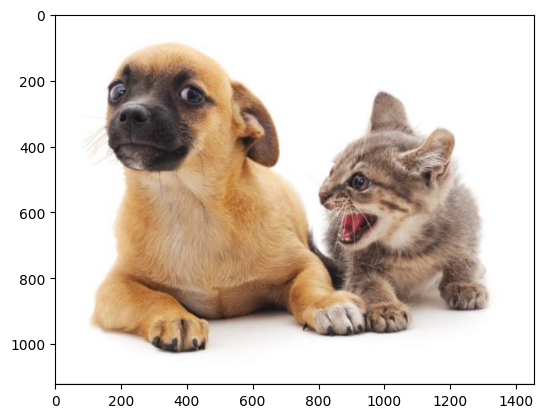

In [ ]:
print('input image shape:', img.permute(1, 2, 0).shape)
plt.imshow(img.permute(1, 2, 0));
print('output image shape:', out_img.shape)
plt.imshow(out_img);

In a fully convolutional network, we initialize the transposed convolutional layer with upsampling by bilinear interpolation. For the $1\times 1$ convolutional layer, we use Xavier initialization.

In [ ]:
W = bilinear_kernel(num_classes, num_classes, 64)
net.transpose_conv.weight.data.copy_(W);

**NOTE**: At this point, the memory is almost full, so we need to restart the session. We do this by calling the `exit` function.

In [ ]:
exit()

Now, we need to rerun all the previously introduced functions, which we do in the cell below.

In [ ]:
import torch
import torchvision
from torch import nn
from torch.nn import functional as F
from PIL import Image
from matplotlib import pyplot as plt
import os
import requests
import zipfile
import tarfile

def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """Plot a list of images."""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    plt.tight_layout()
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # Tensor Image
            ax.imshow(img.numpy())
        else:
            # PIL Image
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

def download(url, cache_dir=os.path.join('..', 'data')):
    """Download a file, return the local filename."""
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
        return fname
    print(f'Downloading {fname} from {url}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

def download_extract(url, folder=None):
    """Download and extract a zip file."""
    fname = download(url)
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    elif ext in ('.tar', '.gz'):
        fp = tarfile.open(fname, 'r')
    else:
        assert False, 'Only zip/tar files can be extracted.'
    fp.extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else data_dir

def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

def read_voc_images(voc_dir, is_train=True):
    """Read all VOC feature and label images."""
    txt_fname = os.path.join(voc_dir, 'ImageSets', 'Segmentation',
                             'train.txt' if is_train else 'val.txt')
    mode = torchvision.io.image.ImageReadMode.RGB
    with open(txt_fname, 'r') as f:
        images = f.read().split()
    features, labels = [], []
    for i, fname in enumerate(images):
        features.append(torchvision.io.read_image(os.path.join(
            voc_dir, 'JPEGImages', f'{fname}.jpg')))
        labels.append(torchvision.io.read_image(os.path.join(
            voc_dir, 'SegmentationClass' ,f'{fname}.png'), mode))
    return features, labels

VOC_COLORMAP = [[0, 0, 0], [128, 0, 0], [0, 128, 0], [128, 128, 0],
                [0, 0, 128], [128, 0, 128], [0, 128, 128], [128, 128, 128],
                [64, 0, 0], [192, 0, 0], [64, 128, 0], [192, 128, 0],
                [64, 0, 128], [192, 0, 128], [64, 128, 128], [192, 128, 128],
                [0, 64, 0], [128, 64, 0], [0, 192, 0], [128, 192, 0],
                [0, 64, 128]]

VOC_CLASSES = ['background', 'aeroplane', 'bicycle', 'bird', 'boat',
               'bottle', 'bus', 'car', 'cat', 'chair', 'cow',
               'diningtable', 'dog', 'horse', 'motorbike', 'person',
               'potted plant', 'sheep', 'sofa', 'train', 'tv/monitor']

def voc_colormap2label():
    """Build the mapping from RGB to class indices for VOC labels."""
    colormap2label = torch.zeros(256 ** 3, dtype=torch.long)
    for i, colormap in enumerate(VOC_COLORMAP):
        colormap2label[
            (colormap[0] * 256 + colormap[1]) * 256 + colormap[2]] = i
    return colormap2label

def voc_label_indices(colormap, colormap2label):
    """Map any RGB values in VOC labels to their class indices."""
    colormap = colormap.permute(1, 2, 0).numpy().astype('int32')
    idx = ((colormap[:, :, 0] * 256 + colormap[:, :, 1]) * 256
           + colormap[:, :, 2])
    return colormap2label[idx]

def voc_rand_crop(feature, label, height, width):
    """Randomly crop both feature and label images."""
    rect = torchvision.transforms.RandomCrop.get_params(
        feature, (height, width))
    feature = torchvision.transforms.functional.crop(feature, *rect)
    label = torchvision.transforms.functional.crop(label, *rect)
    return feature, label

class VOCSegDataset(torch.utils.data.Dataset):
    """A customized dataset to load the VOC dataset."""

    def __init__(self, is_train, crop_size, voc_dir):
        self.transform = torchvision.transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        self.crop_size = crop_size
        features, labels = read_voc_images(voc_dir, is_train=is_train)
        self.features = [self.normalize_image(feature)
                         for feature in self.filter(features)]
        self.labels = self.filter(labels)
        self.colormap2label = voc_colormap2label()
        print('read ' + str(len(self.features)) + ' examples')

    def normalize_image(self, img):
        return self.transform(img.float() / 255)

    def filter(self, imgs):
        return [img for img in imgs if (
            img.shape[1] >= self.crop_size[0] and
            img.shape[2] >= self.crop_size[1])]

    def __getitem__(self, idx):
        feature, label = voc_rand_crop(self.features[idx], self.labels[idx],
                                       *self.crop_size)
        return (feature, voc_label_indices(label, self.colormap2label))

    def __len__(self):
        return len(self.features)

def load_data_voc(batch_size, crop_size):
    """Load the VOC semantic segmentation dataset."""
    voc_dir = download_extract('http://d2l-data.s3-accelerate.amazonaws.com/VOCtrainval_11-May-2012.tar', os.path.join(
        'VOCdevkit', 'VOC2012'))
    num_workers = 2
    train_iter = torch.utils.data.DataLoader(
        VOCSegDataset(True, crop_size, voc_dir), batch_size,
        shuffle=True, drop_last=True, num_workers=num_workers)
    test_iter = torch.utils.data.DataLoader(
        VOCSegDataset(False, crop_size, voc_dir), batch_size,
        drop_last=True, num_workers=num_workers)
    return train_iter, test_iter

def bilinear_kernel(in_channels, out_channels, kernel_size):
    factor = (kernel_size + 1) // 2
    if kernel_size % 2 == 1:
        center = factor - 1
    else:
        center = factor - 0.5
    og = (torch.arange(kernel_size).reshape(-1, 1),
          torch.arange(kernel_size).reshape(1, -1))
    filt = (1 - torch.abs(og[0] - center) / factor) * \
           (1 - torch.abs(og[1] - center) / factor)
    weight = torch.zeros((in_channels, out_channels,
                          kernel_size, kernel_size))
    weight[range(in_channels), range(out_channels), :, :] = filt
    return weight

pretrained_net = torchvision.models.resnet18(weights=torchvision.models.resnet.ResNet18_Weights.DEFAULT)

net = nn.Sequential(*list(pretrained_net.children())[:-2])

num_classes = 21
net.add_module('final_conv', nn.Conv2d(512, num_classes, kernel_size=1))
net.add_module('transpose_conv', nn.ConvTranspose2d(num_classes, num_classes,
                                    kernel_size=64, padding=16, stride=32))

W = bilinear_kernel(num_classes, num_classes, 64)
net.transpose_conv.weight.data.copy_(W);

Next, we read
the semantic segmentation dataset
as introduced in the first section.
The output image shape of random cropping is
specified as $320\times 480$: both the height and width are divisible by $32$.

In [ ]:
batch_size, crop_size = 32, (320, 480)
train_iter, test_iter = load_data_voc(batch_size, crop_size) #1 min

read 1114 examples
read 1078 examples


Now we can train our constructed
fully convolutional network.
The loss function and accuracy calculation here
are not essentially different from those in image classification of earlier laboratories.
Because we use the output channel of the
transposed convolutional layer to
predict the class for each pixel,
the channel dimension is specified in the loss calculation.
In addition, the accuracy is calculated
based on correctness
of the predicted class for all the pixels.

In [ ]:
def accuracy(y_hat, y):
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = torch.argmax(y_hat, axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

def evaluate_accuracy(net, data_iter, device=None):
    if isinstance(net, nn.Module):
        net.eval()  # Set the model to evaluation mode
        if not device:
            device = next(iter(net.parameters())).device
    # No. of correct predictions, no. of predictions
    total_hits = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            X = X.to(device)
            y = y.to(device)
            total_hits += accuracy(net(X), y)
            total_samples += y.numel()
    return total_hits / total_samples * 100

def train_batch(net, X, y, loss, trainer, device):
    X = X.to(device)
    y = y.to(device)
    net.train()
    trainer.zero_grad()
    pred = net(X)
    l = loss(pred, y)
    l.sum().backward()
    trainer.step()
    train_loss_sum = l.sum()
    train_acc_sum = accuracy(pred, y)
    return train_loss_sum, train_acc_sum

def train(net, train_iter, test_iter, loss, trainer, num_epochs,
               device=try_gpu()):
    num_batches = len(train_iter)
    train_loss_all = []
    train_acc_all = []
    test_acc_all = []
    net = net.to(device)
    for epoch in range(num_epochs):
        # Sum of training loss, sum of training accuracy, no. of examples,
        # no. of predictions
        total_loss = 0
        total_acc = 0
        total_samples = 0
        total_predictions = 0
        for i, (features, labels) in enumerate(train_iter):
            l, acc = train_batch(
                net, features, labels, loss, trainer, device)
            total_loss += l
            total_acc += acc
            total_samples += labels.shape[0]
            total_predictions += labels.numel()
        train_loss_all.append(total_loss / total_samples)
        train_acc_all.append(total_acc / total_predictions * 100)
        test_acc = evaluate_accuracy(net, test_iter)
        test_acc_all.append(test_acc)
        print(f'loss {total_loss / total_samples:.3f}, train acc '
            f'{total_acc / total_predictions * 100:.3f}, test acc {test_acc:.3f}')
    return train_acc_all, test_acc_all

def loss(inputs, targets):
    return F.cross_entropy(inputs, targets, reduction='none').mean(1).mean(1)

In [ ]:
num_epochs, lr, wd, device = 5, 0.001, 1e-3, try_gpu()
trainer = torch.optim.SGD(net.parameters(), lr=lr, weight_decay=wd)
train_acc_all, test_acc_all = train(net, train_iter, test_iter, loss, trainer, num_epochs, device) #6 min

loss 1.124, train acc 74.427, test acc 80.022
loss 0.634, train acc 82.544, test acc 83.593
loss 0.508, train acc 84.896, test acc 83.513
loss 0.458, train acc 85.931, test acc 84.896
loss 0.418, train acc 86.870, test acc 85.113


Similar to previous laboratories, we plot the training and test accuracies.

In [ ]:
def plot_accuracy(train_acc_all, test_acc_all):
    epochs = range(1, len(train_acc_all) + 1)
    plt.plot(epochs, train_acc_all, 'bo', label='Training acc')
    plt.plot(epochs, test_acc_all, 'b', label='Test acc')
    plt.title('Training and test accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

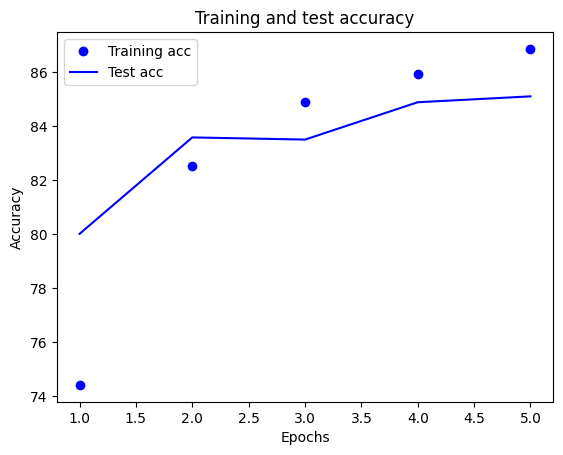

In [ ]:
plot_accuracy(train_acc_all, test_acc_all)

When predicting, we need to standardize the input image
in each channel and transform the image into the four-dimensional input format required by the CNN.

In [ ]:
def predict(img):
    X = test_iter.dataset.normalize_image(img).unsqueeze(0)
    pred = net(X.to(device)).argmax(dim=1)
    return pred.reshape(pred.shape[1], pred.shape[2])

To visualize the predicted class of each pixel, we map the predicted class back to its label color in the dataset.

In [ ]:
def label2image(pred):
    colormap = torch.tensor(VOC_COLORMAP, device=device)
    X = pred.long()
    return colormap[X, :]

Images in the test dataset vary in size and shape.
Since the model uses a transposed convolutional layer with stride of $32$,
when the height or width of an input image is indivisible by $32$,
the output height or width of the
transposed convolutional layer will deviate from the shape of the input image.
In order to address this issue,
we can crop multiple rectangular areas with height and width that are integer multiples of $32$ in the image,
and perform forward propagation
on the pixels in these areas separately.
Note that
the union of these rectangular areas needs to completely cover the input image.
When a pixel is covered by multiple rectangular areas,
the average of the transposed convolution outputs
in separate areas for this same pixel
can be input to
the softmax operation
to predict the class.

For simplicity, we only read a few larger test images,
and crop a $320\times480$ area for prediction starting from the upper-left corner of an image.
For these test images, we
print their cropped areas,
prediction results,
and ground-truth row by row.

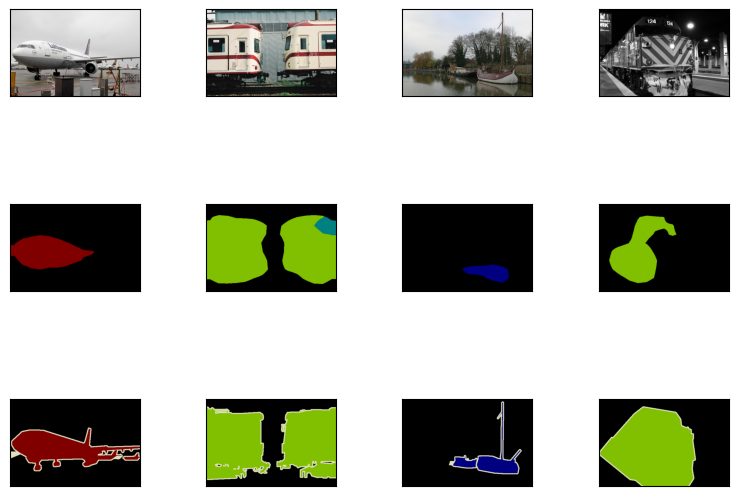

In [ ]:
voc_dir = download_extract('http://d2l-data.s3-accelerate.amazonaws.com/VOCtrainval_11-May-2012.tar', 'VOCdevkit/VOC2012')
test_images, test_labels = read_voc_images(voc_dir, False)
n, imgs = 4, []
for i in range(n):
    crop_rect = (0, 0, 320, 480)
    X = torchvision.transforms.functional.crop(test_images[i], *crop_rect)
    pred = label2image(predict(X))
    imgs += [X.permute(1,2,0), pred.cpu(),
             torchvision.transforms.functional.crop(
                 test_labels[i], *crop_rect).permute(1,2,0)]
show_images(imgs[::3] + imgs[1::3] + imgs[2::3], 3, n, scale=2); #1 min

# Exercises

1. We initialized the transposed convolutional layer by bilinear interpolation. Use Xavier initialization for the transposed convolutional layer and run the necessary experiment. How does the performance change?

2. The original fully convolutional network paper also uses outputs of some intermediate CNN layers to construct the semantic segmentation, like in the figure below. We only implemented FCN-32s using the outputs of the last stage in ResNet-18 (corresponding to `pool5` in the figure below). Implement FCN-16s by using the outputs of the penultimate stage in the ResNet-18 network (corresponding to `pool4` in the figure below).

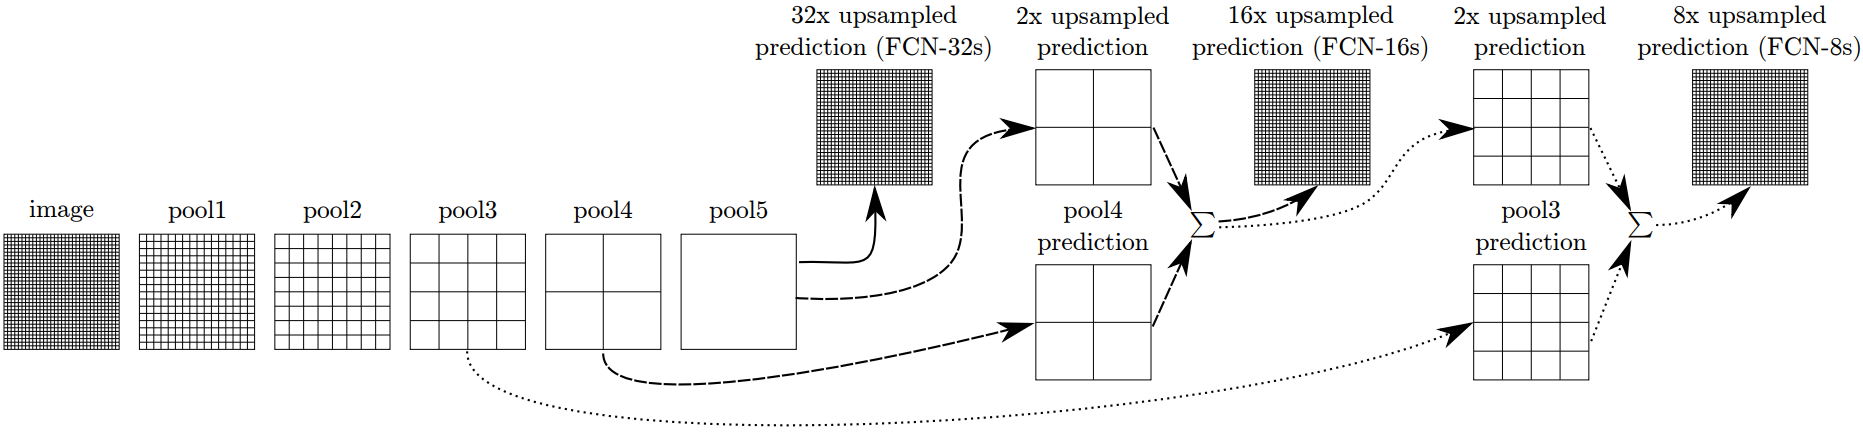